# Chapter 29: The AI as Experiment Designer

*Systems Thinking with AI* by Jason Karpeles

Reduce the uncertainty that most changes the decision, at the least cost, without breaking anything.

**Goal.** Four experiments on the chapter's adoption model. Rank uncertainties by their swing, divide by the cost of finding out and watch the order change, compare one-at-a-time swings with a joint sample, and see why checking only the endpoints of a range can miss a reversal.

**Demonstrations**

1. Rank uncertainties by their swing
2. Rank by what it costs to find out
3. One at a time against a joint sample
4. Endpoints can miss a reversal

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/29-experiments/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/29-experiments/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_13_expressions/code/expressions.py`

In [2]:
%%module chapters.chapter_13_expressions.code.expressions
"""Evaluate a model's algebra without granting it the power to run arbitrary code.

A declarative model spec carries expressions as text. Handing that text to eval()
gives whoever wrote the spec the ability to do anything the process can do. This
module parses to a syntax tree, walks it against a whitelist, and refuses anything
outside it.
"""

import ast
import math
from collections.abc import Callable

ALLOWED_FUNCTIONS: dict[str, Callable[..., float]] = {
    "min": min,
    "max": max,
    "abs": abs,
    "exp": math.exp,
    "log": math.log,
    "sqrt": math.sqrt,
}

_ALLOWED_NODES = (
    ast.Expression, ast.BinOp, ast.UnaryOp, ast.Name, ast.Load, ast.Constant, ast.Call,
    ast.Add, ast.Sub, ast.Mult, ast.Div, ast.Pow, ast.USub, ast.UAdd, ast.Mod,
    ast.Compare, ast.Lt, ast.LtE, ast.Gt, ast.GtE, ast.Eq, ast.NotEq, ast.IfExp,
)


class UnsafeExpression(ValueError):
    """Raised when an expression asks for something the whitelist does not permit."""


def parse(text: str, functions: dict[str, Callable[..., float]] | None = None) -> ast.Expression:
    """Parse an expression and reject every construct outside the whitelist.

    `functions` names what may be called. It defaults to this module's own table,
    and Chapter 23 passes its approved registry in instead, so a model calls what
    a person approved rather than what this file happens to import.
    """
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    if not text.strip():
        raise UnsafeExpression("an expression cannot be empty")
    try:
        tree = ast.parse(text, mode="eval")
    except SyntaxError as exc:
        raise UnsafeExpression(f"not a valid expression: {exc.msg}") from exc
    for node in ast.walk(tree):
        if not isinstance(node, _ALLOWED_NODES):
            raise UnsafeExpression(f"{type(node).__name__} is not permitted in a model expression")
        if isinstance(node, ast.Call):
            if not isinstance(node.func, ast.Name):
                raise UnsafeExpression("only direct calls to whitelisted functions are permitted")
            if node.func.id not in allowed:
                raise UnsafeExpression(f"'{node.func.id}' is not an allowed function")
            if node.keywords:
                raise UnsafeExpression("keyword arguments are not permitted")
        if isinstance(node, ast.Constant) and not isinstance(node.value, (int, float, bool)):
            raise UnsafeExpression("only numeric constants are permitted")
    return tree


def variables(text: str, functions: dict[str, Callable[..., float]] | None = None) -> set[str]:
    """Every name an expression reads. The model's dependency edges come from here."""
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    tree = parse(text, allowed)
    return {n.id for n in ast.walk(tree) if isinstance(n, ast.Name) and n.id not in allowed}


def evaluate(text: str, values: dict[str, float],
             functions: dict[str, Callable[..., float]] | None = None) -> float:
    """Evaluate a whitelisted expression against a supplied set of named values."""
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    tree = parse(text, allowed)
    needed = variables(text, allowed)
    missing = needed - set(values)
    if missing:
        raise ValueError(f"no value supplied for: {sorted(missing)}")
    scope: dict[str, object] = {**allowed, **values}
    return eval(compile(tree, "<model>", "eval"), {"__builtins__": {}}, scope)  # noqa: S307


`chapters/chapter_20_model_document/code/document.py`

In [3]:
%%module chapters.chapter_20_model_document.code.document
"""A model as structured data: validated, versioned, and hashable.

An imperative model is a program. A change to it is a diff of code, and whether
the change altered the model's meaning requires reading the code. A declarative
model is a document, and a change to it is a diff of assumptions.
"""

import hashlib
import json
import re
from dataclasses import MISSING, asdict, dataclass, field, fields

from chapters.chapter_13_expressions.code.expressions import UnsafeExpression, variables

ID_PATTERN = re.compile(r"^[a-z][a-z0-9_]*$")
KINDS = ("stock", "flow", "auxiliary", "parameter", "perception", "lookup", "delay")


@dataclass(frozen=True)
class Variable:
    """One named quantity, with everything needed to place it in the model."""

    id: str
    kind: str
    unit: str
    equation: str = ""
    value: float | None = None
    evidence: str = "assumed"
    note: str = ""
    target: str = ""   # for a flow: which stock it moves
    sign: int = 1      # +1 adds to the target, -1 removes from it
    points: tuple[tuple[float, float], ...] = ()   # for a lookup: the observed shape
    delay_time: float | None = None                # for a delay: its mean, in horizon units

    def __post_init__(self) -> None:
        if not ID_PATTERN.match(self.id):
            raise ValueError(f"'{self.id}' is not a canonical id: lower case, digits, underscores")
        if self.kind not in KINDS:
            raise ValueError(f"kind must be one of {KINDS}")
        if not self.unit.strip():
            raise ValueError(f"'{self.id}' has no unit")
        if self.kind in ("stock", "parameter") and self.value is None:
            raise ValueError(f"'{self.id}' is a {self.kind} and needs a value")
        if self.kind in ("flow", "auxiliary") and not self.equation.strip():
            raise ValueError(f"'{self.id}' is a {self.kind} and needs an equation")
        if self.sign not in (1, -1):
            raise ValueError("sign must be +1 or -1")
        if self.target and self.kind != "flow":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot target a stock")
        if self.kind in ("lookup", "delay") and not self.equation.strip():
            raise ValueError(f"'{self.id}' is a {self.kind} and needs an equation for its input")
        if self.points and self.kind != "lookup":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot carry lookup points")
        if self.kind == "lookup":
            if len(self.points) < 2:
                raise ValueError(f"lookup '{self.id}' needs at least two points")
            xs = [x for x, _ in self.points]
            if xs != sorted(xs) or len(set(xs)) != len(xs):
                raise ValueError(f"lookup '{self.id}' needs points with increasing x")
        if self.delay_time is not None and self.kind != "delay":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot carry a delay time")
        if self.kind == "delay" and (self.delay_time is None or self.delay_time <= 0):
            raise ValueError(f"delay '{self.id}' needs a positive delay_time")


@dataclass
class ModelDocument:
    """The whole model, as data. Nothing here executes."""

    name: str
    version: str
    variables: list[Variable] = field(default_factory=list)
    horizon: int = 1
    horizon_unit: str = "week"
    time_step: float = 1.0

    def __post_init__(self) -> None:
        if not re.match(r"^\d+\.\d+\.\d+$", self.version):
            raise ValueError("version must be semantic: major.minor.patch")
        ids = [v.id for v in self.variables]
        duplicates = {i for i in ids if ids.count(i) > 1}
        if duplicates:
            raise ValueError(f"duplicate ids: {sorted(duplicates)}")
        if self.time_step <= 0 or self.horizon < 1:
            raise ValueError("time_step must be positive and horizon at least 1")

    def by_id(self, name: str) -> Variable:
        for v in self.variables:
            if v.id == name:
                return v
        raise KeyError(f"no variable '{name}' in this model")

    @staticmethod
    def _asserted(variable: "Variable") -> dict:
        """A variable's fields minus the ones sitting at their default.

        A field at its default asserts nothing, so it stays out of the canonical
        form. That is what lets the schema gain a field without changing the hash
        of every document written before it existed.
        """
        defaults = {
            f.name: (f.default if f.default is not MISSING else None) for f in fields(variable)
        }
        return {k: v for k, v in asdict(variable).items() if v != defaults.get(k)}

    def canonical(self) -> str:
        """A stable text form: keys sorted, variables ordered, no incidental whitespace."""
        payload = {
            "name": self.name,
            "horizon": self.horizon,
            "horizon_unit": self.horizon_unit,
            "time_step": self.time_step,
            "variables": sorted(
                (self._asserted(v) for v in self.variables), key=lambda d: d["id"]
            ),
        }
        return json.dumps(payload, sort_keys=True, separators=(",", ":"))

    def hash(self) -> str:
        """Content hash of the model's meaning. Excludes the version deliberately."""
        return hashlib.sha256(self.canonical().encode()).hexdigest()[:16]


def validate(document: ModelDocument) -> list[str]:
    """Every problem findable without running anything."""
    problems = []
    known = {v.id for v in document.variables}
    for variable in document.variables:
        if variable.kind == "parameter" and variable.evidence == "observed" and not variable.note:
            problems.append(f"'{variable.id}' claims observation with no source note")
        if variable.equation:
            try:
                referenced = variables(variable.equation)
            except UnsafeExpression as exc:
                problems.append(f"'{variable.id}' has an invalid expression: {exc}")
            else:
                for name in sorted(referenced - known):
                    problems.append(f"'{variable.id}' references undefined '{name}'")
    stocks = {v.id for v in document.variables if v.kind == "stock"}
    for variable in document.variables:
        if variable.kind == "flow":
            if not variable.target:
                problems.append(f"flow '{variable.id}' does not say which stock it moves")
            elif variable.target not in stocks:
                problems.append(f"flow '{variable.id}' targets '{variable.target}', not a stock")
    for stock in sorted(stocks):
        moved = [v for v in document.variables if v.kind == "flow" and v.target == stock]
        if not moved:
            problems.append(f"stock '{stock}' has no flow: nothing can change it")
    if not stocks and not any(v.kind == "delay" for v in document.variables):
        problems.append("no stock or delay: nothing in this model carries state")
    return problems


def diff(old: ModelDocument, new: ModelDocument) -> dict[str, object]:
    """What changed between two versions, in the model's own terms."""
    old_ids = {v.id: v for v in old.variables}
    new_ids = {v.id: v for v in new.variables}
    changed = [
        i for i in old_ids.keys() & new_ids.keys() if asdict(old_ids[i]) != asdict(new_ids[i])
    ]
    return {
        "added": sorted(new_ids.keys() - old_ids.keys()),
        "removed": sorted(old_ids.keys() - new_ids.keys()),
        "changed": sorted(changed),
        "fields": {
            f.name: {"before": getattr(old, f.name), "after": getattr(new, f.name)}
            for f in fields(old)
            if f.name != "variables" and getattr(old, f.name) != getattr(new, f.name)
        },
        "variables": {
            name: {"before": asdict(old_ids[name]) if name in old_ids else None,
                   "after": asdict(new_ids[name]) if name in new_ids else None}
            for name in sorted(set(changed) | (old_ids.keys() ^ new_ids.keys()))
        },
    }


`chapters/chapter_15_lookups/code/lookup.py`

In [4]:
%%module chapters.chapter_15_lookups.code.lookup
"""A lookup that interpolates inside its evidence and refuses outside it."""

from bisect import bisect_left


class OutsideDomain(ValueError):
    """Raised when a lookup is asked about a region no observation covers."""


class Lookup:
    """Piecewise-linear interpolation over observed points, with a closed domain."""

    def __init__(self, points: list[tuple[float, float]], name: str = "lookup") -> None:
        if len(points) < 2:
            raise ValueError("a lookup needs at least two observed points")
        ordered = sorted(points)
        xs = [x for x, _ in ordered]
        if len(set(xs)) != len(xs):
            raise ValueError("a lookup cannot hold two values for the same input")
        self.name = name
        self.xs = xs
        self.ys = [y for _, y in ordered]

    @property
    def domain(self) -> tuple[float, float]:
        return self.xs[0], self.xs[-1]

    def __call__(self, x: float) -> float:
        low, high = self.domain
        # A solver that lands on a domain end arrives a few machine epsilons past
        # it. Refusing that is refusing arithmetic, not refusing extrapolation, so
        # an input within a hair of an end is snapped to it and anything further
        # out is still refused.
        tolerance = 1e-9 * max(1.0, abs(low), abs(high))
        if low - tolerance <= x < low:
            x = low
        elif high < x <= high + tolerance:
            x = high
        if not low <= x <= high:
            raise OutsideDomain(
                f"{self.name} was asked about {x}, outside its observed domain [{low}, {high}]"
            )
        i = bisect_left(self.xs, x)
        if self.xs[i] == x:
            return self.ys[i]
        x0, x1, y0, y1 = self.xs[i - 1], self.xs[i], self.ys[i - 1], self.ys[i]
        return y0 + (y1 - y0) * (x - x0) / (x1 - x0)

    def is_monotonic(self) -> bool:
        """True when the relationship never reverses direction."""
        up = all(b >= a for a, b in zip(self.ys, self.ys[1:], strict=False))
        down = all(b <= a for a, b in zip(self.ys, self.ys[1:], strict=False))
        return up or down

    def is_bounded_by(self, low: float, high: float) -> bool:
        return all(low <= y <= high for y in self.ys)


def fit_polynomial(points: list[tuple[float, float]], degree: int) -> list[float]:
    """Least-squares polynomial coefficients, lowest order first. Deliberately naive."""
    n = degree + 1
    if len(points) < n:
        raise ValueError("not enough points for that degree")
    xs = [x for x, _ in points]
    ys = [y for _, y in points]
    a = [[sum(x ** (i + j) for x in xs) for j in range(n)] for i in range(n)]
    b = [sum(y * x**i for x, y in zip(xs, ys, strict=True)) for i in range(n)]
    for col in range(n):
        pivot = max(range(col, n), key=lambda r: abs(a[r][col]))
        if abs(a[pivot][col]) < 1e-12:
            raise ValueError("the fit is singular at this degree")
        a[col], a[pivot] = a[pivot], a[col]
        b[col], b[pivot] = b[pivot], b[col]
        for r in range(n):
            if r == col:
                continue
            factor = a[r][col] / a[col][col]
            a[r] = [x - factor * y for x, y in zip(a[r], a[col], strict=True)]
            b[r] -= factor * b[col]
    return [b[i] / a[i][i] for i in range(n)]


def evaluate_polynomial(coefficients: list[float], x: float) -> float:
    """A fit will answer any question asked of it. That is the problem."""
    return sum(c * x**i for i, c in enumerate(coefficients))


`chapters/chapter_08_causal_graph/code/graph.py`

In [5]:
%%module chapters.chapter_08_causal_graph.code.graph
"""A causal graph whose links carry evidence status and time semantics.

A link with no evidence status and no delay is a drawing. This module refuses to
treat one as a finding.
"""

from dataclasses import dataclass

EVIDENCE_LEVELS = ("observed", "inferred", "assumed", "proposed")


@dataclass(frozen=True)
class Link:
    """One causal claim: source, target, sign, how it is known, and whether it is delayed."""

    source: str
    target: str
    polarity: int  # +1 same direction, -1 opposite direction
    evidence: str
    delayed: bool | None = None  # None means nobody recorded the time semantics
    note: str = ""

    def __post_init__(self) -> None:
        if self.polarity not in (1, -1):
            raise ValueError("polarity must be +1 or -1")
        if self.evidence not in EVIDENCE_LEVELS:
            raise ValueError(f"evidence must be one of {EVIDENCE_LEVELS}")
        if self.source == self.target:
            raise ValueError("a link must join two different variables")


def simple_cycles(outgoing: dict[str, list[str]] | dict[str, set[str]]) -> list[list[str]]:
    """Every simple cycle in a directed graph, each reported once from its lowest node.

    Kept separate from the link list so the same enumeration can run on a graph
    derived from equations, which is what Chapter 21's compiler does with it.
    """
    loops: list[list[str]] = []
    seen: set[tuple[str, ...]] = set()

    def walk(start: str, node: str, path: list[str]) -> None:
        for nxt in sorted(outgoing.get(node, [])):
            if nxt == start:
                rotation = tuple(path)
                if min(path) == path[0] and rotation not in seen:
                    seen.add(rotation)
                    loops.append(list(path))
            elif nxt not in path:
                walk(start, nxt, path + [nxt])

    for node in sorted(outgoing):
        walk(node, node, [node])
    return loops


def find_loops(links: list[Link]) -> list[list[str]]:
    """Enumerate every simple feedback loop, each reported once from its lowest node."""
    outgoing: dict[str, list[str]] = {}
    for link in links:
        outgoing.setdefault(link.source, []).append(link.target)
    return simple_cycles(outgoing)


def loop_polarity(loop: list[str], links: list[Link]) -> str:
    """Reinforcing when the loop holds an even number of negative links, balancing otherwise."""
    index = {(link.source, link.target): link.polarity for link in links}
    negatives = 0
    for i, node in enumerate(loop):
        nxt = loop[(i + 1) % len(loop)]
        polarity = index.get((node, nxt))
        if polarity is None:
            raise ValueError(f"no link from {node} to {nxt}")
        if polarity < 0:
            negatives += 1
    return "reinforcing" if negatives % 2 == 0 else "balancing"


def unsupported_links(links: list[Link]) -> list[Link]:
    """Links resting on assumption or proposal rather than observation or inference."""
    return [link for link in links if link.evidence in ("assumed", "proposed")]


def links_without_time_semantics(links: list[Link]) -> list[Link]:
    """Links where nobody recorded whether the effect is immediate or delayed."""
    return [link for link in links if link.delayed is None]


def audit(links: list[Link]) -> dict[str, int]:
    """Summarize what the diagram is resting on."""
    loops = find_loops(links)
    return {
        "links": len(links),
        "loops": len(loops),
        "reinforcing": sum(1 for loop in loops if loop_polarity(loop, links) == "reinforcing"),
        "balancing": sum(1 for loop in loops if loop_polarity(loop, links) == "balancing"),
        "unsupported": len(unsupported_links(links)),
        "no_time_semantics": len(links_without_time_semantics(links)),
    }


`chapters/chapter_21_compiler/code/compiler.py`

In [6]:
%%module chapters.chapter_21_compiler.code.compiler
"""Turn a model document into an evaluation order, or say precisely why it cannot.

Two kinds of cycle exist in a model and they need opposite treatment. A cycle
through a stock is feedback: legitimate, and resolved by the time step. A cycle
through auxiliaries alone is an algebraic loop. It may have a mathematical solution,
but this compiler has no simultaneous-equation solver and must refuse it.
"""

from chapters.chapter_08_causal_graph.code.graph import simple_cycles
from chapters.chapter_13_expressions.code.expressions import variables
from chapters.chapter_20_model_document.code.document import ModelDocument

# A delay carries its own level between steps, so a cycle through one closes over
# a time step exactly as a cycle through a stock does.
STATEFUL = ("stock", "delay")


def edges(document: ModelDocument) -> dict[str, set[str]]:
    """What each variable reads, derived from its equation rather than declared."""
    graph: dict[str, set[str]] = {v.id: set() for v in document.variables}
    known = set(graph)
    for variable in document.variables:
        if variable.equation:
            graph[variable.id] = {n for n in variables(variable.equation) if n in known}
    return graph


def declared_versus_inferred(
    document: ModelDocument, declared: dict[str, set[str]]
) -> dict[str, set[str]]:
    """Edges someone wrote down that the equations do not support, and the reverse."""
    inferred = edges(document)
    out: dict[str, set[str]] = {}
    # Sorted so the report reads the same way twice. Set order is not stable across runs.
    for node in sorted(set(inferred) | set(declared)):
        missing = declared.get(node, set()) - inferred.get(node, set())
        extra = inferred.get(node, set()) - declared.get(node, set())
        if missing or extra:
            out[node] = missing | extra
    return out


def strongly_connected(graph: dict[str, set[str]]) -> list[list[str]]:
    """Tarjan's algorithm. Every group of nodes that can all reach each other."""
    index: dict[str, int] = {}
    low: dict[str, int] = {}
    stack: list[str] = []
    on_stack: set[str] = set()
    result: list[list[str]] = []
    counter = 0

    def walk(node: str) -> None:
        nonlocal counter
        index[node] = low[node] = counter
        counter += 1
        stack.append(node)
        on_stack.add(node)
        for nxt in sorted(graph.get(node, ())):
            if nxt not in index:
                walk(nxt)
                low[node] = min(low[node], low[nxt])
            elif nxt in on_stack:
                low[node] = min(low[node], index[nxt])
        if low[node] == index[node]:
            group = []
            while True:
                member = stack.pop()
                on_stack.discard(member)
                group.append(member)
                if member == node:
                    break
            result.append(sorted(group))

    for node in sorted(graph):
        if node not in index:
            walk(node)
    return result


def algebraic_loops(document: ModelDocument) -> list[list[str]]:
    """Cycles with no stateful node, unsupported by this explicit runtime."""
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    graph = {k: {x for x in v if x not in stateful} for k, v in edges(document).items()}
    graph = {k: v for k, v in graph.items() if k not in stateful}
    return [
        group
        for group in strongly_connected(graph)
        if len(group) > 1 or any(group[0] in graph.get(group[0], set()) for _ in (0,))
    ]


def influence(document: ModelDocument) -> dict[str, set[str]]:
    """The graph the other way round: what each variable affects, not what it reads.

    `edges` answers the compiler's question, which is what a variable depends on.
    A loop is a path of influence, so enumerating loops needs the arrows reversed.
    """
    reversed_graph: dict[str, set[str]] = {v.id: set() for v in document.variables}
    for name, reads in edges(document).items():
        for source in reads:
            reversed_graph[source].add(name)
    # A flow reaches its stock through the target field rather than an equation,
    # so that arrow is absent from `edges` and is exactly where a loop closes.
    for variable in document.variables:
        if variable.kind == "flow" and variable.target:
            reversed_graph[variable.id].add(variable.target)
    return reversed_graph


def feedback_loops(document: ModelDocument) -> list[list[str]]:
    """Every feedback loop in the model, enumerated from the equations.

    Chapter 8 enumerates loops in a graph somebody drew. This runs the same
    enumeration over the graph the equations imply, and keeps only the loops that
    pass through something stateful, because those are the ones that close over a
    time step. A cycle with no state in it is an algebraic loop, which
    `algebraic_loops` reports as a defect instead.
    """
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    return [
        loop for loop in simple_cycles(influence(document))
        if any(node in stateful for node in loop)
    ]


def evaluation_order(document: ModelDocument) -> list[str]:
    """Topological order for everything computed within a step.

    Stocks are excluded: their values are state carried in from the previous step,
    so nothing inside a step has to compute them.
    """
    loops = algebraic_loops(document)
    if loops:
        raise ValueError(f"cannot order a model with algebraic loops: {loops}")
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    graph = {
        k: {x for x in v if x not in stateful}
        for k, v in edges(document).items()
        if k not in stateful
    }
    order: list[str] = []
    seen: set[str] = set()

    def visit(node: str) -> None:
        if node in seen:
            return
        seen.add(node)
        for dependency in sorted(graph.get(node, ())):
            visit(dependency)
        order.append(node)

    for node in sorted(graph):
        visit(node)
    return order


def diagnostics(document: ModelDocument) -> list[str]:
    """Compiler output written to teach rather than to scold."""
    messages = []
    for loop in algebraic_loops(document):
        members = ", ".join(loop)
        messages.append(
            f"algebraic component: {{{members}}}. These depend on each other within one step. "
            f"This compiler has no simultaneous-equation solver. Rewrite the equations to remove "
            f"the cycle, or route a link through a stock if the model requires a delay."
        )
    graph = edges(document)
    for node, reads in sorted(graph.items()):
        if node in reads:
            messages.append(f"'{node}' reads itself. A stock does this through time, not algebra.")
    return messages


`chapters/chapter_22_runtime/code/runtime.py`

In [7]:
%%module chapters.chapter_22_runtime.code.runtime
"""What 'run' means: evaluate in order, advance the stocks, record, repeat.

Everything this needs was built in earlier chapters. The document says what exists
(Chapter 20), the compiler says what order to evaluate it in (Chapter 21), the
evaluator computes each expression safely (Chapter 13), and the solver advances the
stocks (Chapter 19). This module is the composition and nothing more.
"""

import random
from dataclasses import dataclass, field

from chapters.chapter_13_expressions.code.expressions import evaluate
from chapters.chapter_15_lookups.code.lookup import Lookup
from chapters.chapter_20_model_document.code.document import ModelDocument, validate
from chapters.chapter_21_compiler.code.compiler import evaluation_order


@dataclass
class RunSettings:
    """The semantics of a run.

    The document supplies the default time step and horizon. Explicit run
    settings override those defaults and travel with the result. Reproduction
    requires the model document, the effective run settings, and the
    implementation version together as a reproduction bundle.
    """

    solver: str = "euler"
    dt: float = 1.0
    horizon: float = 20.0
    seed: int = 0

    def __post_init__(self) -> None:
        if self.solver not in ("euler", "rk4"):
            raise ValueError("solver must be 'euler' or 'rk4'")
        if self.dt <= 0 or self.horizon <= 0:
            raise ValueError("dt and horizon must be positive")


@dataclass
class Result:
    """Everything needed to reproduce and to audit a run."""

    model_hash: str
    settings: RunSettings
    times: list[float] = field(default_factory=list)
    series: dict[str, list[float]] = field(default_factory=dict)

    def final(self, name: str) -> float:
        return self.series[name][-1]


class Runtime:
    """Runs one model document."""

    def __init__(self, document: ModelDocument, settings: RunSettings | None = None) -> None:
        problems = validate(document)
        if problems:
            raise ValueError(f"model does not validate: {problems}")
        self.document = document
        # The document's own time step and horizon are the defaults, because a
        # semantic choice recorded in the document and then ignored by the runtime
        # is decoration. Explicit settings still win: a run may say otherwise, and
        # then it has said so on the record.
        self.settings = settings or RunSettings(
            dt=document.time_step, horizon=float(document.horizon)
        )
        self.order = evaluation_order(document)
        self.stocks = {v.id: float(v.value) for v in document.variables if v.kind == "stock"}
        self.lookups = {
            v.id: Lookup([tuple(p) for p in v.points], name=v.id)
            for v in document.variables if v.kind == "lookup"
        }
        # A first-order delay is a level that fills from its input and drains at
        # level / delay_time. Holding it as state lets the ordinary solver advance
        # it, so no separate stepping machinery is needed.
        self.delays = {v.id: v for v in document.variables if v.kind == "delay"}
        for name, variable in self.delays.items():
            initial_rate = float(variable.value or 0.0)
            self.stocks[self._level(name)] = initial_rate * float(variable.delay_time)
        self.rng = random.Random(self.settings.seed)

    @staticmethod
    def _level(name: str) -> str:
        """State key for a delay's hidden level. Named so a series is readable."""
        return f"{name}__level"

    def _environment(self, state: dict[str, float]) -> dict[str, float]:
        """Evaluate every computed quantity in dependency order from the given state."""
        env: dict[str, float] = dict(state)
        for name, variable in self.delays.items():
            env[name] = state[self._level(name)] / float(variable.delay_time)
        for name in self.order:
            variable = self.document.by_id(name)
            if variable.kind in ("parameter",):
                env[name] = float(variable.value)
            elif variable.kind == "lookup":
                env[name] = self.lookups[name](evaluate(variable.equation, env))
            elif variable.equation:
                env[name] = evaluate(variable.equation, env)
        return env

    def derivatives(self, state: dict[str, float]) -> dict[str, float]:
        """Net rate of change for every stock, from the flows attached to it."""
        env = self._environment(state)
        rates = dict.fromkeys(self.stocks, 0.0)
        for name, variable in self.delays.items():
            rates[self._level(name)] = evaluate(variable.equation, env) - env[name]
        for variable in self.document.variables:
            if variable.kind == "flow" and variable.target:
                rates[variable.target] += variable.sign * env[variable.id]
        return rates

    def _advance(self, state: dict[str, float], dt: float) -> dict[str, float]:
        if self.settings.solver == "euler":
            rates = self.derivatives(state)
            return {k: v + dt * rates[k] for k, v in state.items()}
        k1 = self.derivatives(state)
        s2 = {k: v + dt / 2 * k1[k] for k, v in state.items()}
        k2 = self.derivatives(s2)
        s3 = {k: v + dt / 2 * k2[k] for k, v in state.items()}
        k3 = self.derivatives(s3)
        s4 = {k: v + dt * k3[k] for k, v in state.items()}
        k4 = self.derivatives(s4)
        return {
            k: v + dt * (k1[k] + 2 * k2[k] + 2 * k3[k] + k4[k]) / 6 for k, v in state.items()
        }

    def run(self) -> Result:
        """Advance to the horizon, recording every stock and every computed quantity."""
        dt, horizon = self.settings.dt, self.settings.horizon
        result = Result(model_hash=self.document.hash(), settings=self.settings)
        state = dict(self.stocks)
        t = 0.0
        while True:
            env = self._step(self._environment, state, t)
            result.times.append(t)
            for name, value in env.items():
                result.series.setdefault(name, []).append(value)
            if t >= horizon - 1e-12:
                break
            state = self._step(self._advance, state, t, dt)
            t += dt
        return result

    @staticmethod
    def _step(work, state, t, *args):
        """Run one piece of a step, and say when it failed if it does.

        A trajectory-dependent failure cannot be caught before the run, so the
        least a runtime owes is the time it happened at.
        """
        try:
            return work(state, *args)
        except (ArithmeticError, ValueError, KeyError) as exc:
            raise RuntimeError(f"run failed at time {t:g}: {exc}") from exc

    def checkpoint(self) -> dict[str, float]:
        """The whole of the model's state. Everything else is recomputed from it."""
        return dict(self.stocks)

    def restore(self, checkpoint: dict[str, float]) -> None:
        if set(checkpoint) != set(self.stocks):
            raise ValueError("checkpoint does not match this model's stocks")
        self.stocks = dict(checkpoint)


`chapters/chapter_29_experiments/code/sensitivity.py`

In [8]:
%%module chapters.chapter_29_experiments.code.sensitivity
"""Rank uncertainties by how much they move the decision, not by how uncertain they are."""

import random
from dataclasses import dataclass

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime


@dataclass(frozen=True)
class Uncertainty:
    """One quantity nobody has pinned down, with the range somebody will defend."""

    variable: str
    low: float
    high: float
    cost_to_reduce: float = 0.0   # what it would take to measure it

    def __post_init__(self) -> None:
        if self.low >= self.high:
            raise ValueError(f"{self.variable}: low must be below high")


def _with(document: ModelDocument, overrides: dict[str, float]) -> ModelDocument:
    return ModelDocument(
        name=document.name, version=document.version, horizon=document.horizon,
        horizon_unit=document.horizon_unit, time_step=document.time_step,
        variables=[
            type(v)(**{**v.__dict__, "value": overrides[v.id]}) if v.id in overrides else v
            for v in document.variables
        ],
    )


def metric(document: ModelDocument, overrides: dict[str, float], name: str,
           settings: RunSettings | None = None) -> float:
    """Run a model under overrides and return one decision quantity.

    Explicit settings state a comparison window; the teaching default is 20 model time units
    at step 1. This comparison window is independent of the document's simulation horizon.
    """
    return Runtime(_with(document, overrides), settings or RunSettings()).run().final(name)


def one_at_a_time(document: ModelDocument, uncertainties: list[Uncertainty],
                  decision_metric: str, settings: RunSettings | None = None
                  ) -> dict[str, float]:
    """Swing each uncertainty across its range with the others held at midpoint."""
    base = {u.variable: (u.low + u.high) / 2 for u in uncertainties}
    swings = {}
    for u in uncertainties:
        low = metric(document, {**base, u.variable: u.low}, decision_metric, settings)
        high = metric(document, {**base, u.variable: u.high}, decision_metric, settings)
        swings[u.variable] = abs(high - low)
    return swings


def ranked(document: ModelDocument, uncertainties: list[Uncertainty], decision_metric: str,
           settings: RunSettings | None = None) -> list[tuple[str, float]]:
    """Uncertainties ordered by their effect on the decision metric, largest first."""
    swings = one_at_a_time(document, uncertainties, decision_metric, settings)
    return sorted(swings.items(), key=lambda kv: kv[1], reverse=True)


def value_per_cost(document: ModelDocument, uncertainties: list[Uncertainty],
                   decision_metric: str) -> list[tuple[str, float]]:
    """Output swing divided by stated measurement cost, a screen rather than information value."""
    swings = one_at_a_time(document, uncertainties, decision_metric)
    out = []
    for u in uncertainties:
        if u.cost_to_reduce <= 0:
            continue
        out.append((u.variable, swings[u.variable] / u.cost_to_reduce))
    return sorted(out, key=lambda kv: kv[1], reverse=True)


def sample(document: ModelDocument, uncertainties: list[Uncertainty], decision_metric: str,
           draws: int, seed: int) -> list[float]:
    """Draw uniformly from every range at once and return the metric for each draw."""
    if draws < 1:
        raise ValueError("draws must be at least 1")
    rng = random.Random(seed)
    out = []
    for _ in range(draws):
        overrides = {u.variable: rng.uniform(u.low, u.high) for u in uncertainties}
        out.append(metric(document, overrides, decision_metric))
    return out


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [9]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [10]:
"""Chapter 29 reader: which uncertainty to reduce.

Numbers come from the Chapter 29 pack (Uncertainty, one_at_a_time, ranked, value_per_cost, sample)
running the Bass adoption model of the chapter, so the reader, the pack and the book agree.
"""
from __future__ import annotations

import numpy as np
from readerkit import PALETTE, fmt, new_figure, signed

from chapters.chapter_20_model_document.code.document import ModelDocument, Variable
from chapters.chapter_29_experiments.code.sensitivity import (
    Uncertainty,
    metric,
    one_at_a_time,
    sample,
    value_per_cost,
)

EQ_RANKED = 'ranked(document, uncertainties, "adopters")'
EQ_VPC = 'value_per_cost(document, uncertainties, "adopters")'
EQ_SUM = "f(x, y) = x + y"
EQ_INTERIOR = "1 - (2*p - 1)**2"

MARKET_RANGES = {"wide": (700, 1300), "mid": (850, 1150), "narrow": (950, 1050)}
IMITATION_RANGES = {"wide": (0.1, 0.5), "narrow": (0.2, 0.4)}
INNOVATION = (0.005, 0.02)
NAMES = {"total_market": "Market size", "imitation": "Imitation", "innovation": "Innovation"}


def bass() -> ModelDocument:
    return ModelDocument("bass", "1.0.0", horizon=40, variables=[
        Variable("adopters", "stock", "people", value=1.0),
        Variable("total_market", "parameter", "people", value=1000.0),
        Variable("innovation", "parameter", "1/week", value=0.01),
        Variable("imitation", "parameter", "1/week", value=0.30),
        Variable("potential", "auxiliary", "people", "total_market - adopters"),
        Variable("adoption", "flow", "people/week",
                 "(innovation + imitation * adopters / total_market) * potential",
                 target="adopters", sign=1),
    ])


def _bars(ax, items, color, xmax, unit_fmt=1):
    """Horizontal bars, largest first, with the value written at the end of each."""
    n = len(items)
    for row, (name, value) in enumerate(items):
        y = n - 1 - row
        ax.barh(y, value, color=color, height=0.55)
        ax.annotate(fmt(value, unit_fmt), (value, y), xytext=(5, 0), textcoords="offset points",
                    ha="left", va="center", fontsize=10.5, color=PALETTE["ink"])
    ax.set_yticks(range(n), [NAMES[name] for name, _ in reversed(items)])
    ax.set_xlim(0, xmax)
    ax.set_ylim(-0.6, n - 0.4)


def _tie_note(items, tol=0.05):
    top = items[0][1]
    tied = [NAMES[n] for n, v in items if abs(v - top) <= tol]
    return f" {' and '.join(tied)} tie for first, and the order between them is not settled." if len(tied) > 1 else ""


# Demonstration 1: rank by the swing in the decision metric.

def ranking_by_effect(market="wide", imitation="wide"):
    us = [Uncertainty("total_market", *MARKET_RANGES[market]),
          Uncertainty("imitation", *IMITATION_RANGES[imitation]),
          Uncertainty("innovation", *INNOVATION)]
    swings = one_at_a_time(bass(), us, "adopters")
    items = sorted(swings.items(), key=lambda kv: kv[1], reverse=True)
    mids = {u.variable: (u.low + u.high) / 2 for u in us}
    parts = []
    for u in us:
        lo = metric(bass(), {**mids, u.variable: u.low}, "adopters")
        hi = metric(bass(), {**mids, u.variable: u.high}, "adopters")
        parts.append(f"{NAMES[u.variable]} |{fmt(hi, 1)} - {fmt(lo, 1)}| = {fmt(swings[u.variable], 1)}")

    fig, ax = new_figure()
    _bars(ax, items, PALETTE["navy"], 760)
    ax.set_xlabel("Swing in adopters at week 20 across the range (people)")
    ax.set_ylabel("Uncertain quantity")

    metrics = {"Ranked first": NAMES[items[0][0]]}
    for name, value in items:
        metrics[f"Swing, {NAMES[name].lower()}"] = fmt(value, 1)
    metrics["Ranges"] = (f"market {MARKET_RANGES[market][0]} to {MARKET_RANGES[market][1]}, imitation "
                         f"{IMITATION_RANGES[imitation][0]} to {IMITATION_RANGES[imitation][1]}, innovation 0.005 to 0.02")
    interpretation = (
        "Each swing runs the model at the low and high end of one range with the others at their midpoints: "
        + "; ".join(parts) + f". The largest is {NAMES[items[0][0]].lower()}.{_tie_note(items)}"
    )
    alt = (
        "Horizontal bars of the swing in final adopters for market size, imitation and innovation, largest first: "
        + ", ".join(f"{NAMES[n].lower()} {fmt(v, 1)}" for n, v in items) + "."
    )
    return fig, metrics, interpretation, alt


# Demonstration 2: divide by the cost of finding out.

def ranking_by_cost(cost_market=20.0, cost_innovation=1.0):
    us = [Uncertainty("total_market", 700, 1300, cost_to_reduce=float(cost_market)),
          Uncertainty("imitation", 0.1, 0.5, cost_to_reduce=5.0),
          Uncertainty("innovation", 0.005, 0.02, cost_to_reduce=float(cost_innovation))]
    swings = one_at_a_time(bass(), us, "adopters")
    by_effect = sorted(swings.items(), key=lambda kv: kv[1], reverse=True)
    by_value = value_per_cost(bass(), us, "adopters")
    costs = {u.variable: u.cost_to_reduce for u in us}

    fig, (left, right) = new_figure(ncols=2)
    _bars(left, by_effect, PALETTE["navy"], 780)
    left.set_xlabel("Swing (people)")
    left.set_ylabel("Uncertain quantity")
    left.set_title("By effect", fontsize=11.5)
    _bars(right, by_value, PALETTE["teal"], 480)
    right.set_xlabel("Swing per unit of cost")
    right.set_ylabel("Uncertain quantity")
    right.set_title("By effect per cost", fontsize=11.5)

    reversed_order = by_effect[0][0] != by_value[0][0]
    metrics = {"First by effect": NAMES[by_effect[0][0]], "First by effect per cost": NAMES[by_value[0][0]],
               "Order reversed": "yes" if reversed_order else "no"}
    for n, v in by_value:
        metrics[f"Per cost, {NAMES[n].lower()}"] = fmt(v, 1)
    calc = "; ".join(f"{NAMES[n]} {fmt(swings[n], 1)} / {fmt(costs[n], 0)} = {fmt(v, 1)}" for n, v in by_value)
    tail = (f"Per cost, {NAMES[by_value[0][0]].lower()} comes first instead of {NAMES[by_effect[0][0]].lower()}, so the order reverses." if reversed_order
            else "The largest effect is also the best value, so the order does not reverse.")
    interpretation = f"Effect divided by cost: {calc}. {tail}{_tie_note(by_value)}"
    alt = (
        f"Two panels of horizontal bars. By effect the order is {', '.join(NAMES[n].lower() for n, _ in by_effect)}; "
        f"by effect per cost it is {', '.join(NAMES[n].lower() for n, _ in by_value)}."
    )
    return fig, metrics, interpretation, alt


# Demonstration 3: one-at-a-time swings against a joint sample.

def joint_sample(draws=20, seed=1):
    us = [Uncertainty("imitation", 0.1, 0.5), Uncertainty("innovation", 0.005, 0.02)]
    swings = one_at_a_time(bass(), us, "adopters")
    values = sample(bass(), us, "adopters", draws, seed)
    spread = max(values) - min(values)
    biggest = max(swings.values())

    fig, ax = new_figure()
    labels = ["Imitation alone", "Innovation alone", f"Joint sample ({draws} draws)"]
    bars = [swings["imitation"], swings["innovation"], spread]
    colors = [PALETTE["navy"], PALETTE["navy"], PALETTE["gold"]]
    for y, (v, c) in enumerate(zip(reversed(bars), reversed(colors))):
        ax.barh(y, v, color=c, height=0.55)
        ax.annotate(fmt(v, 1), (v, y), xytext=(5, 0), textcoords="offset points", ha="left", va="center",
                    fontsize=10.5)
    ax.set_yticks(range(3), list(reversed(labels)))
    ax.set_xlim(0, 900)
    ax.set_ylim(-0.6, 2.6)
    ax.set_xlabel("Range of adopters at week 20 (people)")
    ax.set_ylabel("How the range was found")

    if spread > biggest + 0.05:
        verdict = "The joint spread is wider than any single swing. That flags outcomes the swings did not cover; it does not prove an interaction."
    elif abs(spread - biggest) <= 0.05:
        verdict = "The joint spread equals the largest single swing, so this sample adds nothing beyond it."
    else:
        verdict = "The joint spread is narrower than the largest single swing, because a few draws can miss the extremes. A small sample cannot rule out an interaction."
    metrics = {
        "Draws and seed": f"{draws} draws, seed {seed}",
        "Imitation swing": fmt(swings["imitation"], 1),
        "Innovation swing": fmt(swings["innovation"], 1),
        "Lowest sampled": fmt(min(values), 1),
        "Highest sampled": fmt(max(values), 1),
        "Joint spread": fmt(spread, 1),
    }
    interpretation = (
        f"Joint spread = {fmt(max(values), 1)} - {fmt(min(values), 1)} = {fmt(spread, 1)}, against the largest single "
        f"swing {fmt(biggest, 1)}, a difference of {fmt(spread, 1)} - {fmt(biggest, 1)} = {signed(spread - biggest, 1)}. {verdict}"
    )
    alt = (
        f"Three horizontal bars: the swing from imitation alone {fmt(swings['imitation'], 1)}, from innovation alone "
        f"{fmt(swings['innovation'], 1)}, and the spread of {draws} joint draws, {fmt(spread, 1)}."
    )
    return fig, metrics, interpretation, alt


# Demonstration 4: endpoints can hide an interior reversal.

def interior_reversal(a_score=0.2, p=0.5):
    def b_score(q):
        return 1 - (2 * q - 1) ** 2

    b = b_score(p)
    grid = np.linspace(0, 1, 201)
    fig, ax = new_figure()
    ax.plot(grid, [b_score(q) for q in grid], color=PALETTE["teal"], linewidth=2)
    ax.axhline(a_score, color=PALETTE["terracotta"], linewidth=2)
    ax.plot([0, 1], [b_score(0), b_score(1)], "s", color=PALETTE["grey"], markersize=8, markerfacecolor="white")
    ax.axvline(p, color=PALETTE["grey"], linestyle="dashed", linewidth=1.2)
    ax.plot([p], [b], "o", color=PALETTE["ink"], markersize=8)
    ax.text(0.5, 1.12, "B: 1 - (2p - 1)^2", color=PALETTE["teal"], ha="center", va="bottom", fontsize=10.5)
    ax.text(0.98, a_score + 0.03, f"A: {fmt(a_score, 2)}", color=PALETTE["terracotta"], ha="right", va="bottom",
            fontsize=10.5, bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": "none", "alpha": 0.9})
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.1, 1.3)
    ax.set_xlabel("Uncertain quantity p (squares mark the two endpoints)")
    ax.set_ylabel("Score (larger is preferred)")

    if abs(b - a_score) < 1e-9:
        verdict = "tie"
        words = f"A and B tie at p = {fmt(p, 2)}, and the comparison does not decide between them there."
    elif b > a_score:
        verdict = "B wins"
        words = f"B beats A at p = {fmt(p, 2)}."
    else:
        verdict = "A wins"
        words = f"A beats B at p = {fmt(p, 2)}."
    s = 2 * p - 1
    metrics = {
        "A score": fmt(a_score, 2),
        "B score at the point checked": fmt(b, 2),
        "Winner at the point checked": verdict,
        "B score at p = 0 and p = 1": fmt(b_score(0), 2),
        "Winner at both endpoints": "A" if a_score > 0 else "tie",
    }
    interpretation = (
        f"At p = {fmt(p, 2)}: B = 1 - {signed(s, 2)} x {signed(s, 2)} = {fmt(b, 2)}, against A = {fmt(a_score, 2)}. "
        f"{words} At p = 0 and p = 1, B = 1 - (-1) x (-1) = 0, so A wins at both endpoints; checking only "
        f"the endpoints would stop the search for a reversal too early."
    )
    alt = (
        f"B's score rises from 0 at p = 0 to 1 at p = 0.5 and falls back to 0 at p = 1, crossing A's flat line at "
        f"{fmt(a_score, 2)}; the point checked is p = {fmt(p, 2)}, where {verdict.lower()}."
    )
    return fig, metrics, interpretation, alt


## 1. Rank uncertainties by their swing

*Which uncertain quantity moves the decision metric most?*

A wide range moves the metric more than a narrow one, so a quantity can fall down the ranking once its range is pinned down, whatever its importance in the model.

    ranked(document, uncertainties, "adopters")

**Symbols and inputs.** The decision metric is adopters at week 20 from a market of 1000. The swing of one quantity is the absolute change in the metric from the low to the high end of its range, with the others at midpoint.

**Predict first.** With the market range narrowed to 950 to 1050, does market size still rank first?

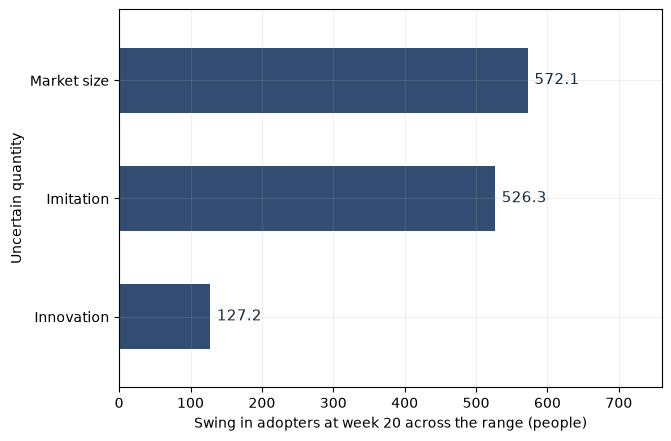

- **Ranked first:** Market size
- **Swing, market size:** 572.1
- **Swing, imitation:** 526.3
- **Swing, innovation:** 127.2
- **Ranges:** market 700 to 1300, imitation 0.1 to 0.5, innovation 0.005 to 0.02

Each swing runs the model at the low and high end of one range with the others at their midpoints: Market size |1240.9 - 668.8| = 572.1; Imitation |999.6 - 473.3| = 526.3; Innovation |978.8 - 851.6| = 127.2. The largest is market size.

In [11]:
show(ranking_by_effect(market='wide', imitation='wide'))

**Use the idea.** Rank by swing before commissioning measurement, so effort goes where the decision moves.

**Where the conclusion applies.** One-at-a-time swings with the others at midpoint. The method misses interactions, and the ranges are defined for this reader, not measured.

*Constructed example: the chapter's three uncertainties and ranges, with narrower ranges defined for this reader, ranked by the chapter's one_at_a_time function.*

Every setting the interactive reader offers for this demonstration:

In [12]:
sweep(ranking_by_effect, [('market', ['wide', 'mid', 'narrow']), ('imitation', ['wide', 'narrow'])])

- **market = wide, imitation = wide**: Ranked first Market size; Swing, market size 572.1; Swing, imitation 526.3; Swing, innovation 127.2; Ranges market 700 to 1300, imitation 0.1 to 0.5, innovation 0.005 to 0.02
- **market = wide, imitation = narrow**: Ranked first Market size; Swing, market size 572.1; Swing, imitation 207.8; Swing, innovation 127.2; Ranges market 700 to 1300, imitation 0.2 to 0.4, innovation 0.005 to 0.02
- **market = mid, imitation = wide**: Ranked first Imitation; Swing, imitation 526.3; Swing, market size 286.0; Swing, innovation 127.2; Ranges market 850 to 1150, imitation 0.1 to 0.5, innovation 0.005 to 0.02
- **market = mid, imitation = narrow**: Ranked first Market size; Swing, market size 286.0; Swing, imitation 207.8; Swing, innovation 127.2; Ranges market 850 to 1150, imitation 0.2 to 0.4, innovation 0.005 to 0.02
- **market = narrow, imitation = wide**: Ranked first Imitation; Swing, imitation 526.3; Swing, innovation 127.2; Swing, market size 95.3; Ranges market 950 to 1050, imitation 0.1 to 0.5, innovation 0.005 to 0.02
- **market = narrow, imitation = narrow**: Ranked first Imitation; Swing, imitation 207.8; Swing, innovation 127.2; Swing, market size 95.3; Ranges market 950 to 1050, imitation 0.2 to 0.4, innovation 0.005 to 0.02

## 2. Rank by what it costs to find out

*Does the biggest uncertainty deserve the first measurement?*

Dividing by cost can reverse the order. An expensive study of a large swing can lose to a cheap estimate of a small one. If the large one becomes cheap enough, it moves back to first.

    value_per_cost(document, uncertainties, "adopters")

**Symbols and inputs.** Value per cost is the swing divided by the stated cost to reduce the uncertainty, a screening heuristic rather than the expected value of information. Costs are in arbitrary units: imitation costs 5, and the market and innovation costs are the controls.

**Predict first.** At the chapter's costs of 20, 5 and 1, which uncertainty comes first once cost is included?

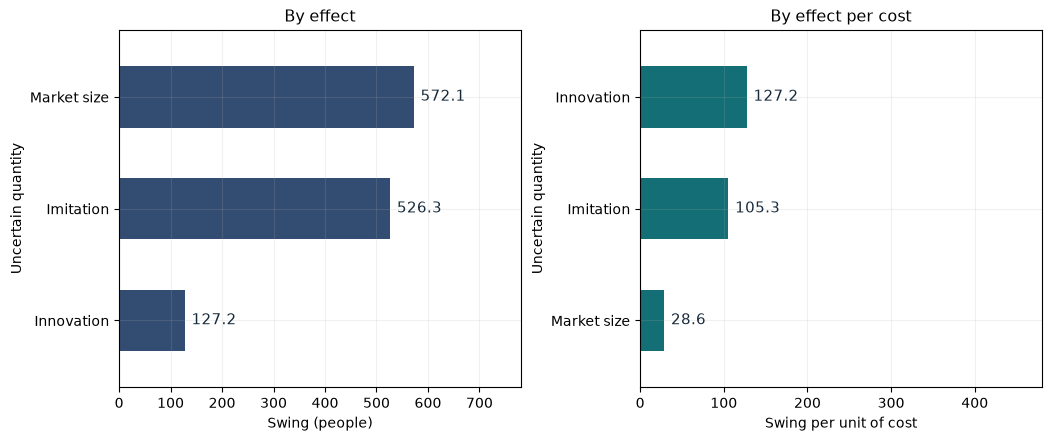

- **First by effect:** Market size
- **First by effect per cost:** Innovation
- **Order reversed:** yes
- **Per cost, innovation:** 127.2
- **Per cost, imitation:** 105.3
- **Per cost, market size:** 28.6

Effect divided by cost: Innovation 127.2 / 1 = 127.2; Imitation 526.3 / 5 = 105.3; Market size 572.1 / 20 = 28.6. Per cost, innovation comes first instead of market size, so the order reverses.

In [13]:
show(ranking_by_cost(cost_market=20.0, cost_innovation=1.0))

**Use the idea.** Estimate the cost of reducing each of the top uncertainties before choosing which to study.

**Where the conclusion applies.** Costs are single numbers in one unit, and measurement removes the uncertainty entirely. Real studies shrink a range only partly.

*Constructed example: the chapter's ranges and costs 20, 5 and 1, with other costs defined for this reader, computed by the chapter's value_per_cost function.*

Every setting the interactive reader offers for this demonstration:

In [14]:
sweep(ranking_by_cost, [('cost_market', [20.0, 5.0, 2.0]), ('cost_innovation', [1.0, 4.0])])

- **cost_market = 20.0, cost_innovation = 1.0**: First by effect Market size; First by effect per cost Innovation; Order reversed yes; Per cost, innovation 127.2; Per cost, imitation 105.3; Per cost, market size 28.6
- **cost_market = 20.0, cost_innovation = 4.0**: First by effect Market size; First by effect per cost Imitation; Order reversed yes; Per cost, imitation 105.3; Per cost, innovation 31.8; Per cost, market size 28.6
- **cost_market = 5.0, cost_innovation = 1.0**: First by effect Market size; First by effect per cost Innovation; Order reversed yes; Per cost, innovation 127.2; Per cost, market size 114.4; Per cost, imitation 105.3
- **cost_market = 5.0, cost_innovation = 4.0**: First by effect Market size; First by effect per cost Market size; Order reversed no; Per cost, market size 114.4; Per cost, imitation 105.3; Per cost, innovation 31.8
- **cost_market = 2.0, cost_innovation = 1.0**: First by effect Market size; First by effect per cost Market size; Order reversed no; Per cost, market size 286.0; Per cost, innovation 127.2; Per cost, imitation 105.3
- **cost_market = 2.0, cost_innovation = 4.0**: First by effect Market size; First by effect per cost Market size; Order reversed no; Per cost, market size 286.0; Per cost, imitation 105.3; Per cost, innovation 31.8

## 3. One at a time against a joint sample

*Does a sample across all ranges at once reveal more than the individual swings?*

For an additive f(x, y) = x + y on [0, 1] each swing is one and the joint range is two. A wider joint spread flags outcomes the swings did not cover, but a small sample can miss the extremes.

    f(x, y) = x + y

**Symbols and inputs.** The two uncertainties are imitation (0.1 to 0.5) and innovation (0.005 to 0.02). Each draw picks both uniformly at random from their ranges. The seed fixes the draws.

**Predict first.** Is the joint spread of a five-draw sample wider than the largest single swing?

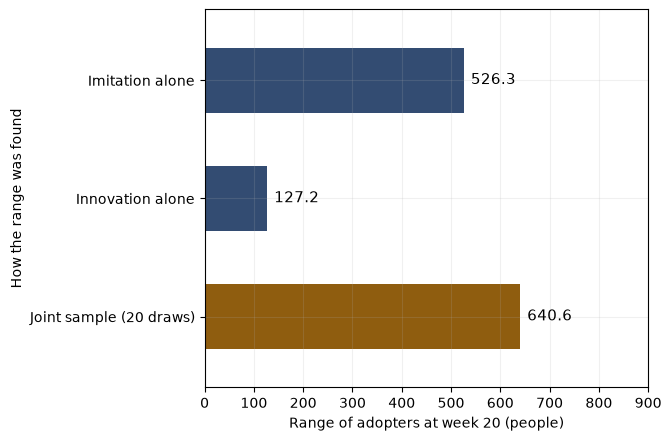

- **Draws and seed:** 20 draws, seed 1
- **Imitation swing:** 526.3
- **Innovation swing:** 127.2
- **Lowest sampled:** 358.3
- **Highest sampled:** 998.9
- **Joint spread:** 640.6

Joint spread = 998.9 - 358.3 = 640.6, against the largest single swing 526.3, a difference of 640.6 - 526.3 = 114.3. The joint spread is wider than any single swing. That flags outcomes the swings did not cover; it does not prove an interaction.

In [15]:
show(joint_sample(draws=20, seed=1))

**Use the idea.** Follow a ranking with a few dozen joint draws as a screen, and record the region sampled.

**Where the conclusion applies.** Uniform draws, two uncertainties, and a fixed seed. A similar spread does not prove independence.

*Constructed example: the chapter's imitation and innovation ranges on its model, sampled with the chapter's sample function; the additive example is the chapter's own.*

Every setting the interactive reader offers for this demonstration:

In [16]:
sweep(joint_sample, [('draws', [5, 20, 60]), ('seed', [1, 2])])

- **draws = 5, seed = 1**: Draws and seed 5 draws, seed 1; Imitation swing 526.3; Innovation swing 127.2; Lowest sampled 358.3; Highest sampled 992.0; Joint spread 633.7
- **draws = 5, seed = 2**: Draws and seed 5 draws, seed 2; Imitation swing 526.3; Innovation swing 127.2; Lowest sampled 351.2; Highest sampled 999.7; Joint spread 648.5
- **draws = 20, seed = 1**: Draws and seed 20 draws, seed 1; Imitation swing 526.3; Innovation swing 127.2; Lowest sampled 358.3; Highest sampled 998.9; Joint spread 640.6
- **draws = 20, seed = 2**: Draws and seed 20 draws, seed 2; Imitation swing 526.3; Innovation swing 127.2; Lowest sampled 293.5; Highest sampled 999.7; Joint spread 706.2
- **draws = 60, seed = 1**: Draws and seed 60 draws, seed 1; Imitation swing 526.3; Innovation swing 127.2; Lowest sampled 358.3; Highest sampled 999.8; Joint spread 641.4
- **draws = 60, seed = 2**: Draws and seed 60 draws, seed 2; Imitation swing 526.3; Innovation swing 127.2; Lowest sampled 293.5; Highest sampled 999.7; Joint spread 706.2

## 4. Endpoints can miss a reversal

*If one policy wins at both ends of a range, does it win throughout?*

B scores 0 at both endpoints and 1 at the middle, so a check of the endpoints finds A ahead while an interior value reverses the order. Without a property such as monotonicity, test interior points.

    1 - (2*p - 1)**2

**Symbols and inputs.** p is an uncertain quantity between 0 and 1. Policy A scores a constant. Policy B scores 1 - (2p - 1)^2. Larger scores are preferred.

**Predict first.** Where A scores 0.2, which policy wins at p = 0.5, though A wins at both endpoints?

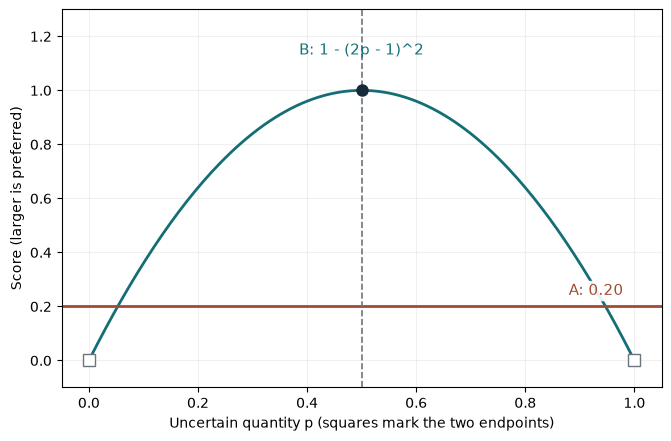

- **A score:** 0.20
- **B score at the point checked:** 1.00
- **Winner at the point checked:** B wins
- **B score at p = 0 and p = 1:** 0.00
- **Winner at both endpoints:** A

At p = 0.50: B = 1 - 0.00 x 0.00 = 1.00, against A = 0.20. B beats A at p = 0.50. At p = 0 and p = 1, B = 1 - (-1) x (-1) = 0, so A wins at both endpoints; checking only the endpoints would stop the search for a reversal too early.

In [17]:
show(interior_reversal(a_score=0.2, p=0.5))

**Use the idea.** Compare policies at interior values and near thresholds before stopping the search for a reversal.

**Where the conclusion applies.** Two policies and one uncertain quantity. This is the chapter's own constructed example, plain arithmetic rather than a chapter function, and finite sampling is never a proof.

*Constructed example: the chapter's own scores, A at 0.2 and B at 1 - (2p - 1)^2, with A at 0.75 added by this reader to show a tie.*

Every setting the interactive reader offers for this demonstration:

In [18]:
sweep(interior_reversal, [('a_score', [0.2, 0.75]), ('p', [0.0, 0.25, 0.5, 1.0])])

- **a_score = 0.2, p = 0.0**: A score 0.20; B score at the point checked 0.00; Winner at the point checked A wins; B score at p = 0 and p = 1 0.00; Winner at both endpoints A
- **a_score = 0.2, p = 0.25**: A score 0.20; B score at the point checked 0.75; Winner at the point checked B wins; B score at p = 0 and p = 1 0.00; Winner at both endpoints A
- **a_score = 0.2, p = 0.5**: A score 0.20; B score at the point checked 1.00; Winner at the point checked B wins; B score at p = 0 and p = 1 0.00; Winner at both endpoints A
- **a_score = 0.2, p = 1.0**: A score 0.20; B score at the point checked 0.00; Winner at the point checked A wins; B score at p = 0 and p = 1 0.00; Winner at both endpoints A
- **a_score = 0.75, p = 0.0**: A score 0.75; B score at the point checked 0.00; Winner at the point checked A wins; B score at p = 0 and p = 1 0.00; Winner at both endpoints A
- **a_score = 0.75, p = 0.25**: A score 0.75; B score at the point checked 0.75; Winner at the point checked tie; B score at p = 0 and p = 1 0.00; Winner at both endpoints A
- **a_score = 0.75, p = 0.5**: A score 0.75; B score at the point checked 1.00; Winner at the point checked B wins; B score at p = 0 and p = 1 0.00; Winner at both endpoints A
- **a_score = 0.75, p = 1.0**: A score 0.75; B score at the point checked 0.00; Winner at the point checked A wins; B score at p = 0 and p = 1 0.00; Winner at both endpoints A

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

If the market range is 950 to 1050 and imitation is 0.1 to 0.5, which is ranked first?

<details><summary>Answer</summary>

Imitation, with a swing of about 526, ahead of innovation at about 127 and market size at about 95.

</details>

### Exercise 2

If measuring market size cost 5 and innovation cost 4, what is market size's value per cost?

<details><summary>Answer</summary>

572.1 / 5 = 114.4, ahead of imitation at 105.3 and innovation at 127.2 / 4 = 31.8, so market size leads.

</details>

### Exercise 3

For f(x, y) = x + y on [0, 1] for each, what are each swing and the joint range?

<details><summary>Answer</summary>

Each swing is 1 - 0 = 1, and the joint range is 2 - 0 = 2, although the effects are additive.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/